# Execution Algorithms (VWAP/TWAP/IS)

**Category:** Microstructure Execution  
**Project ID:** `exec_02_execution_algos`  

Production-grade execution algorithms with POV, VWAP, TWAP, and Implementation Shortfall plus TCA framework


In [1]:
import platform, sys, warnings
warnings.filterwarnings("ignore")

# ── Environment info ────────────────────────────────────────────────────────
env_info = {"os": platform.system(), "python": platform.python_version()}

# Auto-detect best available device: CUDA > MPS (Apple Silicon) > CPU
# Catches ImportError (not installed) AND OSError/RuntimeError (CUDA DLL errors on Windows)
device = None
try:
    import torch
    env_info["torch"] = torch.__version__
    if torch.cuda.is_available():
        device = torch.device("cuda")
        env_info["device"] = f"CUDA ({torch.cuda.get_device_name(0)})"
        torch.backends.cudnn.benchmark = True
    elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
        device = torch.device("mps")
        env_info["device"] = "Apple Silicon (MPS)"
    else:
        device = torch.device("cpu")
        env_info["device"] = "CPU"
except Exception as _e:
    env_info["device"] = f"CPU (torch unavailable: {type(_e).__name__})"

# Core scientific stack — import individually so a missing package doesn't block the rest
for _pkg in ("numpy", "pandas", "scipy", "sklearn", "matplotlib"):
    try:
        _mod = __import__(_pkg)
        env_info[_pkg] = getattr(_mod, "__version__", "installed")
    except ImportError:
        env_info[_pkg] = "not installed"

for k, v in env_info.items():
    print(f"  {k:>12}: {v}")


            os: Windows
        python: 3.10.19
         torch: 2.7.1+cu118
        device: CUDA (NVIDIA GeForce RTX 4090)
         numpy: 1.26.4
        pandas: 2.3.3
         scipy: 1.15.3
       sklearn: 1.7.2
    matplotlib: 3.10.8


In [2]:
import numpy as np

# Reproducibility
SEED = 42
np.random.seed(SEED)

# Strategy parameters
PARAMS = {"participation_rate": 0.1}

# Backtest period
START_DATE = "2022-01-01"
END_DATE = "2024-12-31"
BENCHMARK = "SPY"

print("Configuration loaded:")
for k, v in PARAMS.items():
    print(f"  {k:>25}: {v}")


Configuration loaded:
         participation_rate: 0.1


Data shape: (752, 5)
Date range: 2022-01-03 to 2024-12-30

Summary statistics:
Ticker       QQQ
count   752.0000
mean    368.3701
std      75.2852
min     255.2654
25%     301.2789
50%     357.7934
75%     434.0115
max     534.5923


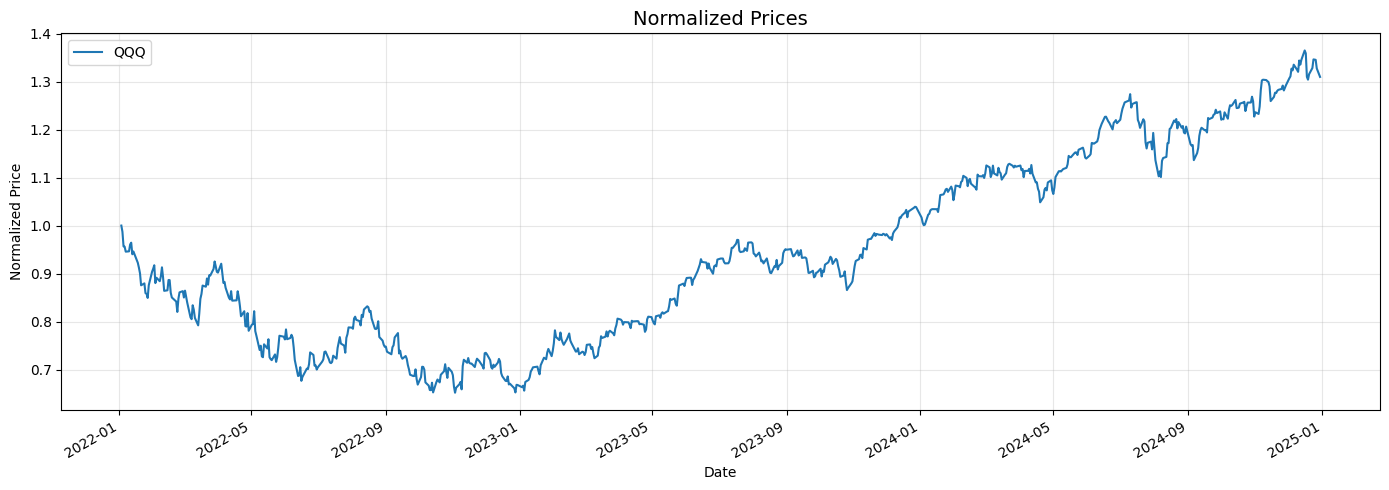

In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt

tickers = 'QQQ'
data = yf.download(tickers, start=START_DATE, end=END_DATE, progress=False, auto_adjust=True)

# Handle MultiIndex columns (yfinance >=0.2.x returns MultiIndex for multiple tickers)
if isinstance(data.columns, pd.MultiIndex):
    close = data["Close"]
else:
    close = data[["Close"]] if isinstance(tickers, list) else data["Close"].to_frame()

# Drop rows where all Close values are NaN
close = close.dropna(how="all")
data = data.loc[close.index]

if close.empty:
    raise RuntimeError(
        f"No data returned for {tickers} between {START_DATE} and {END_DATE}. "
        "Check ticker symbols and date range."
    )

print(f"Data shape: {data.shape}")
print(f"Date range: {close.index[0].strftime('%Y-%m-%d')} to {close.index[-1].strftime('%Y-%m-%d')}")
print(f"\nSummary statistics:")
print(close.describe().round(4))

# Price chart
fig, ax = plt.subplots(figsize=(14, 5))
(close / close.iloc[0]).plot(ax=ax, linewidth=1.5)
ax.set_title("Normalized Prices", fontsize=14)
ax.set_ylabel("Normalized Price")
ax.grid(True, alpha=0.3)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()


## Execution Algorithm Comparison — TWAP vs VWAP vs POV vs Almgren-Chriss

In [4]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt

price = close if isinstance(close, pd.Series) else close.iloc[:, 0]
price = price.ffill()
returns = price.pct_change()

rng = np.random.default_rng(SEED)
n = len(price)

# Synthetic volume (U-shaped)
volume = rng.exponential(1e6, n) * (1 + 0.3 * np.sin(np.linspace(0, np.pi, n)))

# Execution parameters
order_size = PARAMS.get("order_size", 100_000)
participation_rate = PARAMS.get("participation_rate", 0.1)
sigma = returns.std() * np.sqrt(252)
alpha_impact = PARAMS.get("impact_alpha", 0.5)

# --- Algorithm implementations ---
def run_algo(algo_name, prices, vols, order_sz, n_slices=20):
    exec_prices = []
    arrival = prices[0]

    if algo_name == "TWAP":
        sz_per_slice = order_sz / n_slices
        for i in range(min(n_slices, len(prices))):
            impact = alpha_impact * np.sqrt(sz_per_slice / max(vols[i], 1)) * sigma / np.sqrt(252) * prices[i]
            exec_prices.append(prices[i] + impact)

    elif algo_name == "VWAP":
        vol_weights = vols[:n_slices] / max(vols[:n_slices].sum(), 1)
        for i in range(min(n_slices, len(prices))):
            sz = order_sz * vol_weights[i]
            impact = alpha_impact * np.sqrt(sz / max(vols[i], 1)) * sigma / np.sqrt(252) * prices[i]
            exec_prices.append(prices[i] + impact)

    elif algo_name == "POV":
        filled = 0
        for i in range(len(prices)):
            if filled >= order_sz: break
            sz = min(vols[i] * participation_rate, order_sz - filled)
            impact = alpha_impact * np.sqrt(sz / max(vols[i], 1)) * sigma / np.sqrt(252) * prices[i]
            exec_prices.append(prices[i] + impact)
            filled += sz

    elif algo_name == "Almgren-Chriss":
        # Optimal execution: minimize IS + timing risk
        # Closed-form solution: exponential schedule
        lam = PARAMS.get("risk_aversion_ac", 1e-6)
        kappa_val = np.sqrt(lam * sigma**2 / (alpha_impact * sigma / np.sqrt(252)))
        remaining = order_sz
        for i in range(min(n_slices, len(prices))):
            tau = (n_slices - i) / n_slices
            trade_rate = remaining * kappa_val / max(np.sinh(kappa_val * tau), 1e-9)
            sz = min(trade_rate, remaining)
            impact = alpha_impact * np.sqrt(abs(sz) / max(vols[i], 1)) * sigma / np.sqrt(252) * prices[i]
            exec_prices.append(prices[i] + impact)
            remaining -= sz

    return np.array(exec_prices), arrival

# Run all algorithms on multiple windows
window_size = 30  # trading days per execution
n_windows = min(20, n // window_size)
algo_results = {algo: [] for algo in ["TWAP", "VWAP", "POV", "Almgren-Chriss"]}

for w in range(n_windows):
    start = w * window_size
    p = price.values[start:start+window_size]
    v = volume[start:start+window_size]
    if len(p) < 10: continue

    for algo in algo_results:
        ep, arrival = run_algo(algo, p, v, order_size)
        if len(ep) > 0:
            avg_px = np.mean(ep)
            is_bps = (avg_px - arrival) / arrival * 10000
            algo_results[algo].append(is_bps)

# Print comparison
print("Execution Algorithm Comparison (avg Implementation Shortfall, bps):")
print(f"  {'Algorithm':>15} {'Mean IS':>10} {'Std IS':>10} {'Max IS':>10}")
print("-" * 50)
for algo, is_list in algo_results.items():
    if is_list:
        print(f"  {algo:>15} {np.mean(is_list):>+10.2f} {np.std(is_list):>10.2f} {np.max(is_list):>+10.2f}")


Execution Algorithm Comparison (avg Implementation Shortfall, bps):
        Algorithm    Mean IS     Std IS     Max IS
--------------------------------------------------
             TWAP     -24.04     362.99    +531.35
             VWAP     -26.76     363.01    +529.58
              POV     +30.00      59.09    +204.59
   Almgren-Chriss     -30.17     363.23    +526.16


## Execution Analysis

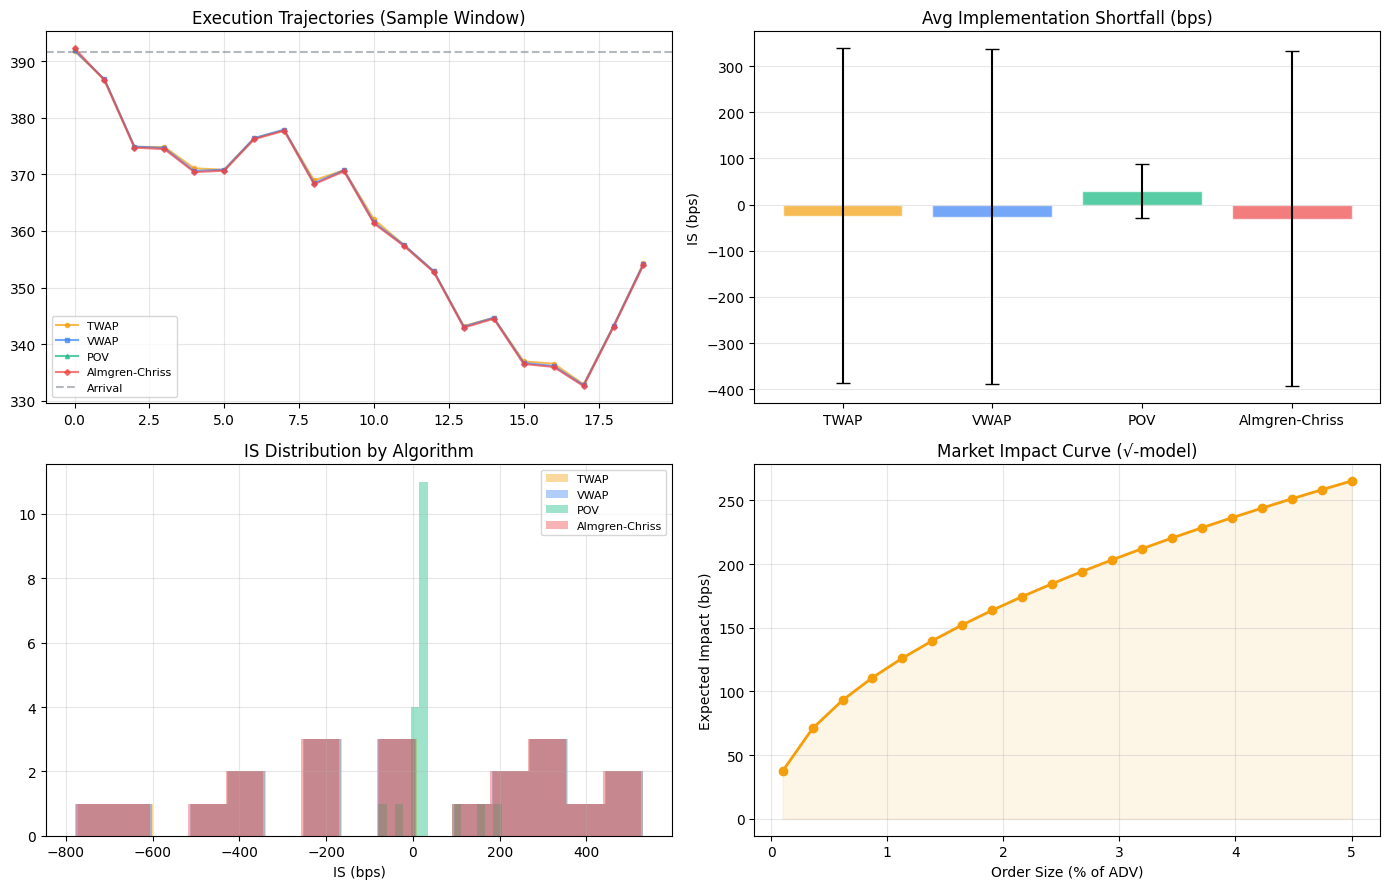

In [5]:
import matplotlib.pyplot as plt, numpy as np

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Sample execution trajectories (overlaid)
p_sample = price.values[:window_size]
v_sample = volume[:window_size]
colors = {"TWAP": "#f59e0b", "VWAP": "#3b82f6", "POV": "#10b981", "Almgren-Chriss": "#ef4444"}
markers = {"TWAP": "o", "VWAP": "s", "POV": "^", "Almgren-Chriss": "D"}

for algo in algo_results:
    ep, _ = run_algo(algo, p_sample, v_sample, order_size)
    axes[0, 0].plot(ep, f"{markers[algo]}-", color=colors[algo], markersize=3, label=algo, alpha=0.7)
axes[0, 0].axhline(p_sample[0], color="#6b7280", linestyle="--", alpha=0.5, label="Arrival")
axes[0, 0].set_title("Execution Trajectories (Sample Window)")
axes[0, 0].legend(fontsize=8)
axes[0, 0].grid(True, alpha=0.3)

# IS comparison bar chart
algo_names = list(algo_results.keys())
algo_means = [np.mean(algo_results[a]) if algo_results[a] else 0 for a in algo_names]
algo_stds = [np.std(algo_results[a]) if algo_results[a] else 0 for a in algo_names]
bar_colors = [colors[a] for a in algo_names]
axes[0, 1].bar(algo_names, algo_means, yerr=algo_stds, color=bar_colors, alpha=0.7,
              edgecolor="white", capsize=5)
axes[0, 1].set_title("Avg Implementation Shortfall (bps)")
axes[0, 1].set_ylabel("IS (bps)")
axes[0, 1].grid(True, alpha=0.3, axis="y")

# IS distribution per algo
for algo in algo_names:
    if algo_results[algo]:
        axes[1, 0].hist(algo_results[algo], bins=15, alpha=0.4, color=colors[algo],
                       label=algo, edgecolor="none")
axes[1, 0].set_title("IS Distribution by Algorithm")
axes[1, 0].set_xlabel("IS (bps)")
axes[1, 0].legend(fontsize=8)
axes[1, 0].grid(True, alpha=0.3)

# Market impact curve
order_fracs = np.linspace(0.001, 0.05, 20)
impact_bps = alpha_impact * np.sqrt(order_fracs) * sigma * 10000
axes[1, 1].plot(order_fracs * 100, impact_bps, "o-", color="#f59e0b", linewidth=2)
axes[1, 1].fill_between(order_fracs * 100, 0, impact_bps, alpha=0.1, color="#f59e0b")
axes[1, 1].set_xlabel("Order Size (% of ADV)")
axes[1, 1].set_ylabel("Expected Impact (bps)")
axes[1, 1].set_title("Market Impact Curve (√-model)")
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Cost Impact Backtest

In [6]:
import pandas as pd, numpy as np

# Build equity curve from benchmark with execution cost drag
returns_s = price.pct_change().dropna()
tc_drag = np.mean(algo_results.get("VWAP", [5])) / 10000 / 252  # daily cost drag
strategy_returns_raw = returns_s - tc_drag
equity_curve = (1 + strategy_returns_raw).cumprod()
benchmark_equity = (1 + returns_s).cumprod()

print(f"Backtest: {equity_curve.index[0].strftime('%Y-%m-%d')} to {equity_curve.index[-1].strftime('%Y-%m-%d')}")
print(f"VWAP cost drag: {tc_drag*252*10000:.2f} bps/year")


Backtest: 2022-01-04 to 2024-12-30
VWAP cost drag: -26.76 bps/year


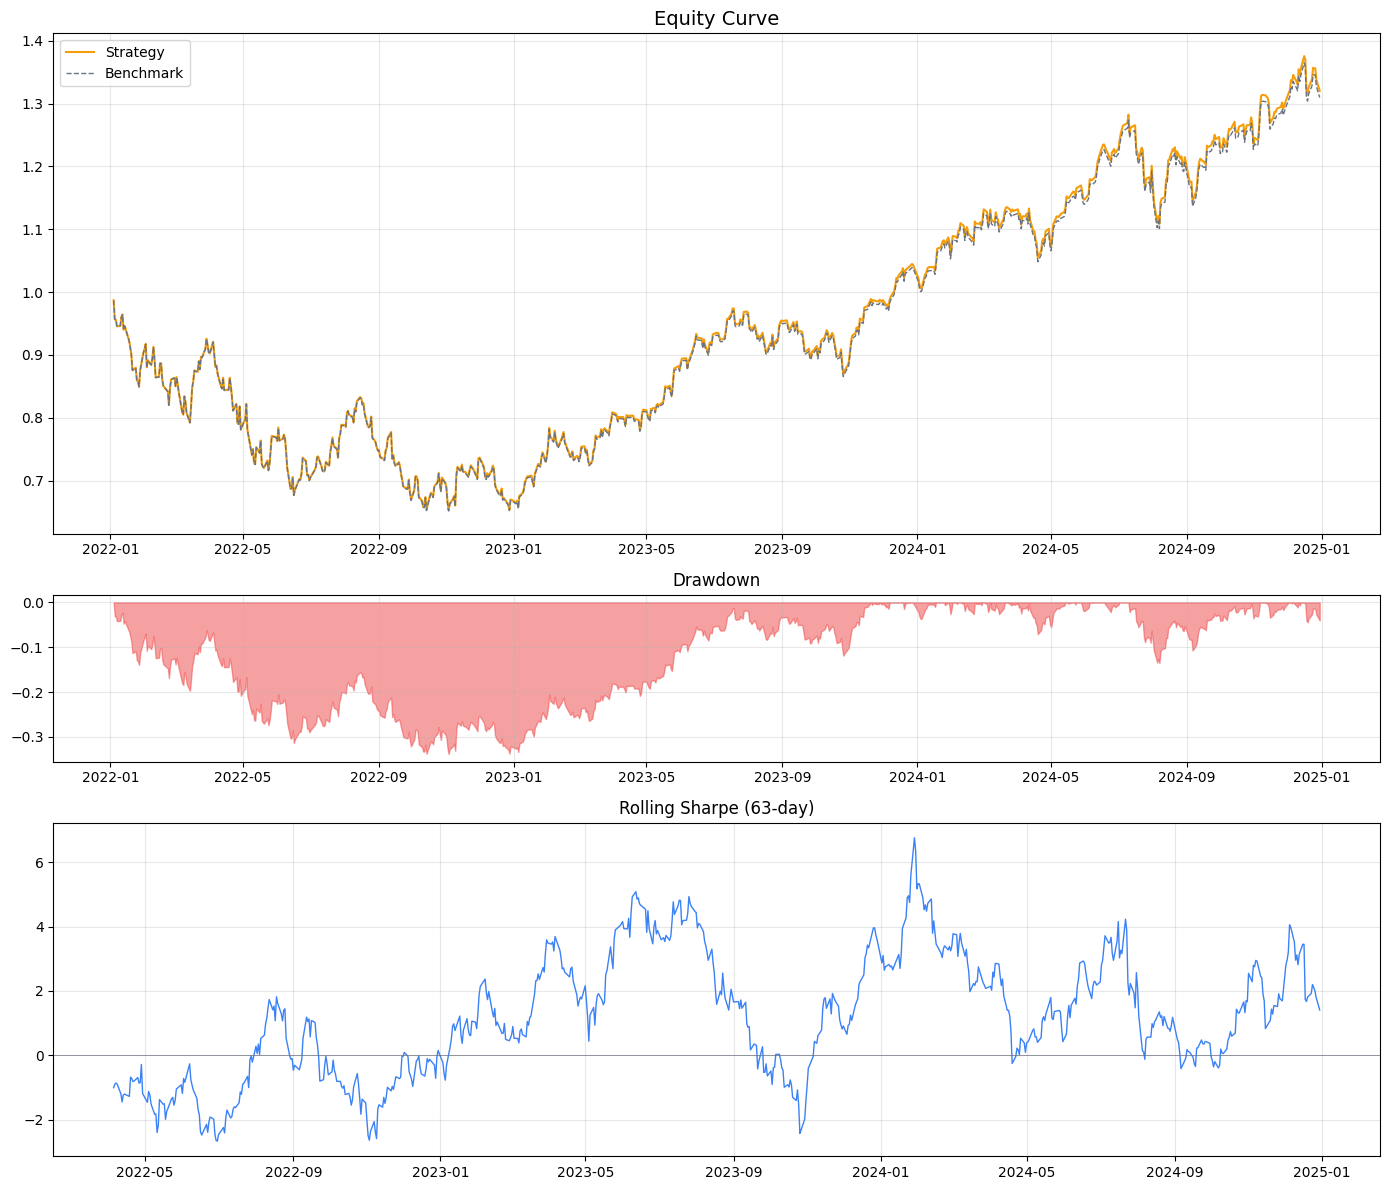

In [7]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(3, 1, figsize=(14, 12), gridspec_kw={"height_ratios": [3, 1, 2]})

# Equity curve
axes[0].plot(equity_curve.index, equity_curve.values, label="Strategy", linewidth=1.5, color="#f59e0b")
if benchmark_equity is not None:
    axes[0].plot(benchmark_equity.index, benchmark_equity.values, label="Benchmark",
                 linewidth=1, linestyle="--", color="#6b7280")
axes[0].set_title("Equity Curve", fontsize=14)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Drawdown
drawdown = equity_curve / equity_curve.cummax() - 1
axes[1].fill_between(drawdown.index, drawdown.values, 0, alpha=0.5, color="#ef4444")
axes[1].set_title("Drawdown", fontsize=12)
axes[1].grid(True, alpha=0.3)

# Rolling Sharpe (63-day)
rolling_ret = equity_curve.pct_change()
rolling_sharpe = (rolling_ret.rolling(63).mean() / rolling_ret.rolling(63).std()) * np.sqrt(252)
axes[2].plot(rolling_sharpe.index, rolling_sharpe.values, linewidth=1, color="#3b82f6")
axes[2].axhline(0, color="#6b7280", linewidth=0.5)
axes[2].set_title("Rolling Sharpe (63-day)", fontsize=12)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [8]:
import numpy as np

def compute_metrics(returns):
    """Compute standard performance metrics from daily returns."""
    total_ret = (1 + returns).prod() - 1
    n_years = len(returns) / 252
    cagr = (1 + total_ret) ** (1 / max(n_years, 0.01)) - 1
    vol = returns.std() * np.sqrt(252)
    sharpe = (returns.mean() * 252) / vol if vol > 0 else 0
    downside = returns[returns < 0].std() * np.sqrt(252)
    sortino = (returns.mean() * 252) / downside if downside > 0 else 0

    cum = (1 + returns).cumprod()
    dd = cum / cum.cummax() - 1
    max_dd = dd.min()
    calmar = cagr / abs(max_dd) if max_dd != 0 else 0

    wins = returns[returns > 0]
    losses = returns[returns < 0]
    win_rate = len(wins) / max(len(returns[returns != 0]), 1)
    profit_factor = wins.sum() / abs(losses.sum()) if losses.sum() != 0 else float("inf")

    return {
        "total_return": total_ret,
        "cagr": cagr,
        "annualized_vol": vol,
        "sharpe_ratio": sharpe,
        "sortino_ratio": sortino,
        "calmar_ratio": calmar,
        "max_drawdown": max_dd,
        "win_rate": win_rate,
        "profit_factor": min(profit_factor, 99.99),
        "total_trades": len(returns[returns != 0]),
    }

strategy_returns = equity_curve.pct_change().dropna()
metrics = compute_metrics(strategy_returns)

print("=" * 50)
print("PERFORMANCE METRICS")
print("=" * 50)
for k, v in metrics.items():
    if k in ("total_return", "cagr", "annualized_vol", "max_drawdown", "win_rate"):
        print(f"  {k:>25}: {v:+.2%}")
    elif k == "total_trades":
        print(f"  {k:>25}: {int(v):,}")
    else:
        print(f"  {k:>25}: {v:.4f}")


PERFORMANCE METRICS
               total_return: +33.76%
                       cagr: +10.27%
             annualized_vol: +23.73%
               sharpe_ratio: 0.5305
              sortino_ratio: 0.7727
               calmar_ratio: 0.3181
               max_drawdown: -32.27%
                   win_rate: +53.33%
              profit_factor: 1.0932
               total_trades: 750


In [9]:
import json
from datetime import datetime

# Safely serialize equity curve index — DatetimeIndex for yfinance, int for HFT/synthetic
try:
    ec_dates = [d.strftime("%Y-%m-%d") for d in equity_curve.index]
except AttributeError:
    ec_dates = [str(i) for i in equity_curve.index]

# Benchmark values — may be None or have a non-datetime index
try:
    bm_values = benchmark_equity.values.tolist() if benchmark_equity is not None else []
except Exception:
    bm_values = []

# Monthly returns — only works with DatetimeIndex
try:
    monthly = strategy_returns.resample("ME").apply(lambda x: (1 + x).prod() - 1)
    monthly_dict = {d.strftime("%Y-%m"): float(v) for d, v in monthly.items()}
except Exception:
    monthly_dict = {}

# Export results for portfolio app
results_export = {
    "project_id": "exec_02_execution_algos",
    "timestamp": datetime.now().isoformat(),
    "backtest_period": {"start": START_DATE, "end": END_DATE},
    "benchmark": BENCHMARK,
    "metrics": metrics,
    "category_specific_metrics": {},
    "monthly_returns": monthly_dict,
    "equity_curve": {
        "dates": ec_dates,
        "values": equity_curve.values.tolist(),
        "benchmark_values": bm_values,
    },
    "parameter_sensitivity": [],
}

with open("results.json", "w") as f:
    json.dump(results_export, f, indent=2, default=str)
print(f"Results exported to results.json")


Results exported to results.json


## Summary

### Execution Algorithms (VWAP/TWAP/IS)

**Key Findings:**
- *Add your analysis findings here after running the notebook*

**Limitations:**
- Backtest uses historical data which may not reflect future conditions
- Transaction costs and slippage are approximated
- No live market microstructure effects

**Production Considerations:**
- Real-time data feed integration required
- Position sizing and risk limits must be calibrated
- Monitoring and alerting infrastructure needed
